# Regressão Logística: Airbnb Lisboa

Projeto Prático 1: Machine Learning

Classificação binária de anúncios caros. A classe positiva (`high_price = 1`) é o anúncio que está no **top 20% de preço dentro do seu grupo** `room_type` × `neighbourhood_cleansed`. A regressão logística é implementada do zero com gradient descent (mini-batch), com regularização L2, termos polinomiais e de interação, validação cruzada, estudos de outliers e de valores em falta e análise do limiar de decisão.

**Pré-requisito:** correr o `data_preparation.ipynb` até ao fim (gera as pastas `data_prepared/`).

### Notas sobre o alvo
- O alvo é definido antes do split e antes do tratamento de outliers, a partir do preço original e do percentil 80 de cada grupo. É uma definição de negócio e não uma estatística aprendida pelo modelo, mas os percentis usam também os anúncios de validação e de teste.
- Como o alvo não depende do tratamento de outliers, as seis combinações de pré-processamento são comparadas sobre os mesmos rótulos de validação e de teste, o que torna a comparação mais justa do que na regressão.
- Com cerca de 20% de positivos, a exatidão (accuracy) sozinha é enganadora: prever sempre "não caro" daria cerca de 80%. A seleção de modelos usa por isso o ROC-AUC e o PR-AUC, que não dependem do limiar.

## 0. Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
SEED = 42

## 1. Função para carregar uma pasta preparada

In [2]:
def carregar_pasta(pasta):
    X_train = pd.read_csv(f"{pasta}/X_train.csv")
    X_val = pd.read_csv(f"{pasta}/X_val.csv")
    X_test = pd.read_csv(f"{pasta}/X_test.csv")
    y_train = pd.read_csv(f"{pasta}/y_train.csv")
    y_val = pd.read_csv(f"{pasta}/y_val.csv")
    y_test = pd.read_csv(f"{pasta}/y_test.csv")
    return {
        "X_train": X_train.values.astype(float), "y_train": y_train["high_price"].values.astype(int),
        "X_val": X_val.values.astype(float), "y_val": y_val["high_price"].values.astype(int),
        "X_test": X_test.values.astype(float), "y_test": y_test["high_price"].values.astype(int),
        "feature_cols": X_train.columns.tolist(),
        "test_df_raw": X_test,
    }

## 2. Regressão logística (implementação do zero)

Modelo `p = sigmoide(X·w)`, função de custo log-loss (entropia cruzada binária) com penalização L2 opcional (o termo constante nunca é penalizado), otimizada por mini-batch gradient descent.

In [3]:
def adicionar_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def prever_proba(X_com_bias, w):
    return sigmoide(X_com_bias @ w)

def custo_logistico(X_com_bias, y, w, l2=0.0):
    n = len(y)
    p = np.clip(prever_proba(X_com_bias, w), 1e-12, 1 - 1e-12)
    perda = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return perda + l2 * np.sum(w[1:] ** 2) / n

def gradiente_logistico(X_com_bias, y, w, l2=0.0):
    n = len(y)
    erro = prever_proba(X_com_bias, w) - y
    grad = (X_com_bias.T @ erro) / n
    grad[1:] += (2 * l2 / n) * w[1:]
    return grad

def treinar_logistica(X, y, lr=0.1, epochs=300, l2=0.0, batch_size=256, seed=SEED):
    rng = np.random.default_rng(seed)
    X_bias = adicionar_bias(X)
    n, d = X_bias.shape
    w = np.zeros(d)
    historico_custo = []
    for _ in range(epochs):
        indices = rng.permutation(n)
        for inicio in range(0, n, batch_size):
            idx = indices[inicio:inicio + batch_size]
            w = w - lr * gradiente_logistico(X_bias[idx], y[idx], w, l2)
        historico_custo.append(custo_logistico(X_bias, y, w, l2))
    return w, historico_custo

## 3. Métricas de classificação, curvas ROC e Precision-Recall

Tudo implementado à mão: matriz de confusão, accuracy, precision, recall, F1, curva ROC, curva Precision-Recall e as respetivas áreas (ROC-AUC e PR-AUC).

In [4]:
def matriz_confusao(y, pred):
    tn = int(np.sum((y == 0) & (pred == 0)))
    fp = int(np.sum((y == 0) & (pred == 1)))
    fn = int(np.sum((y == 1) & (pred == 0)))
    tp = int(np.sum((y == 1) & (pred == 1)))
    return np.array([[tn, fp], [fn, tp]])

def metricas_limiar(y, p, limiar=0.5):
    pred = (p >= limiar).astype(int)
    (tn, fp), (fn, tp) = matriz_confusao(y, pred)
    precisao = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    revocacao = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precisao * revocacao / (precisao + revocacao) if (precisao + revocacao) > 0 else 0.0
    return {"accuracy": (tp + tn) / len(y), "precision": precisao, "recall": revocacao, "F1": f1}

def _ordenar(y, p):
    ordem = np.argsort(-p, kind="mergesort")
    return y[ordem], p[ordem]

def curva_roc(y, p):
    ys, ps = _ordenar(y, p)
    tps, fps = np.cumsum(ys), np.cumsum(1 - ys)
    idx = np.r_[np.where(np.diff(ps))[0], len(ys) - 1]
    return np.r_[0.0, fps[idx] / fps[-1]], np.r_[0.0, tps[idx] / tps[-1]]

def roc_auc(y, p):
    fpr, tpr = curva_roc(y, p)
    return float(np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2))

def curva_pr(y, p):
    ys, ps = _ordenar(y, p)
    tps, fps = np.cumsum(ys), np.cumsum(1 - ys)
    idx = np.r_[np.where(np.diff(ps))[0], len(ys) - 1]
    return tps[idx] / tps[-1], tps[idx] / (tps[idx] + fps[idx])

def pr_auc(y, p):
    revocacao, precisao = curva_pr(y, p)
    return float(np.sum(np.diff(np.r_[0.0, revocacao]) * precisao))

def avaliar_clf(w, X, y, limiar=0.5):
    p = prever_proba(adicionar_bias(X), w)
    return {**metricas_limiar(y, p, limiar), "ROC_AUC": roc_auc(y, p), "PR_AUC": pr_auc(y, p)}

def melhor_limiar(y, p, grelha=np.linspace(0.05, 0.95, 91)):
    f1s = [metricas_limiar(y, p, t)["F1"] for t in grelha]
    return float(grelha[int(np.argmax(f1s))])

def desenhar_matriz_confusao(eixo, y, pred, titulo):
    cm = matriz_confusao(y, pred)
    eixo.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            eixo.text(j, i, f"{cm[i, j]}\n({cm[i, j] / cm[i].sum():.1%} da linha)", ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")
    eixo.set_xticks([0, 1])
    eixo.set_yticks([0, 1])
    eixo.set_xticklabels(["não caro", "caro"])
    eixo.set_yticklabels(["não caro", "caro"])
    eixo.set_xlabel("Previsto")
    eixo.set_ylabel("Real")
    eixo.set_title(titulo)

def desenhar_curvas(eixo_roc, eixo_pr, y, p):
    fpr, tpr = curva_roc(y, p)
    eixo_roc.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc(y, p):.3f}")
    eixo_roc.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="aleatório")
    eixo_roc.set_xlabel("Taxa de falsos positivos")
    eixo_roc.set_ylabel("Taxa de verdadeiros positivos (recall)")
    eixo_roc.set_title("Curva ROC")
    eixo_roc.legend(loc="lower right")
    revocacao, precisao = curva_pr(y, p)
    eixo_pr.plot(revocacao, precisao, label=f"PR-AUC = {pr_auc(y, p):.3f}")
    eixo_pr.axhline(y.mean(), color="k", linestyle="--", linewidth=0.8, label=f"aleatório ({y.mean():.2f})")
    eixo_pr.set_xlabel("Recall")
    eixo_pr.set_ylabel("Precision")
    eixo_pr.set_title("Curva Precision-Recall")
    eixo_pr.legend(loc="upper right")

## 4. Estudo cruzado de pré-processamento (outlier × missing)

Treina o mesmo modelo nas 6 combinações geradas pelo `data_preparation.ipynb`, antes de qualquer outra experiência. O critério de comparação é o ROC-AUC na validação, que não depende do limiar. O modelo é treinado sem regularização L2 (lambda=0); o valor ótimo de lambda só é determinado mais à frente (secção 10), para a combinação escolhida.

In [5]:
resultados_cruzados = []
for missing_strategy in ["simple", "grouped"]:
    for outlier_strategy in ["none", "cap", "drop"]:
        print(f"a treinar {missing_strategy}_{outlier_strategy}...")
        d = carregar_pasta(f"data_prepared/{missing_strategy}_{outlier_strategy}")
        w, _ = treinar_logistica(d["X_train"], d["y_train"], lr=0.1, epochs=150, l2=0.0, batch_size=256)
        resultados_cruzados.append({
            "missing_strategy": missing_strategy,
            "outlier_strategy": outlier_strategy,
            **avaliar_clf(w, d["X_val"], d["y_val"]),
        })

df_cruzado = pd.DataFrame(resultados_cruzados)
df_cruzado

a treinar simple_none...
a treinar simple_cap...
a treinar simple_drop...
a treinar grouped_none...
a treinar grouped_cap...
a treinar grouped_drop...


,missing_strategy,outlier_strategy,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
0,simple,none,0.841532,0.712468,0.397163,0.510018,0.847637,0.629967
1,simple,cap,0.838292,0.690244,0.401418,0.507623,0.845928,0.628863
2,simple,drop,0.835346,0.725309,0.333333,0.456754,0.837161,0.616691
3,grouped,none,0.842415,0.719072,0.395745,0.510522,0.847308,0.633053
4,grouped,cap,0.838586,0.694789,0.397163,0.505415,0.845878,0.632071
5,grouped,drop,0.835641,0.730408,0.330496,0.455078,0.837612,0.620375


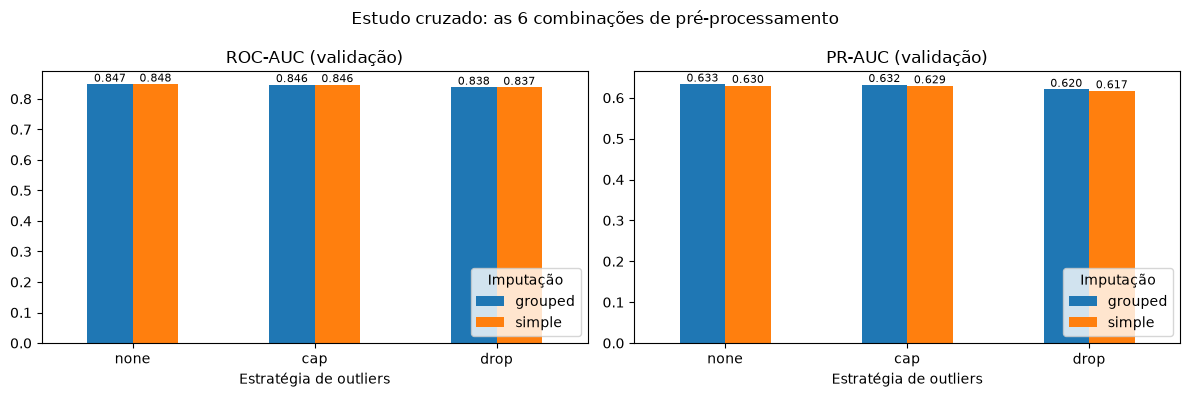

In [6]:
ordem = ["none", "cap", "drop"]
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
for eixo, metrica, titulo in zip(eixos, ["ROC_AUC", "PR_AUC"], ["ROC-AUC (validação)", "PR-AUC (validação)"]):
    tabela = df_cruzado.pivot(index="outlier_strategy", columns="missing_strategy", values=metrica).loc[ordem]
    tabela.plot(kind="bar", ax=eixo, rot=0)
    for cont in eixo.containers:
        eixo.bar_label(cont, fmt="%.3f", fontsize=8)
    eixo.set_xlabel("Estratégia de outliers")
    eixo.set_title(titulo)
    eixo.legend(title="Imputação", loc="lower right")
plt.suptitle("Estudo cruzado: as 6 combinações de pré-processamento")
plt.tight_layout()
plt.show()

### 4.1. Outlier study (média sobre as 2 estratégias de missing)

In [7]:
df_outlier_study = df_cruzado.groupby("outlier_strategy")[["accuracy", "precision", "recall", "F1", "ROC_AUC", "PR_AUC"]].mean().round(4)
df_outlier_study

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
outlier_strategy,,,,,,
cap,0.8384,0.6925,0.3993,0.5065,0.8459,0.6305
drop,0.8355,0.7279,0.3319,0.4559,0.8374,0.6185
none,0.8420,0.7158,0.3965,0.5103,0.8475,0.6315


### Discussão

- **Resultado:** o ROC-AUC é praticamente igual com **none** (**0,847**) e **cap** (**0,846**) e desce com **drop** (**0,837**). O PR-AUC segue o mesmo padrão (0,632; 0,630; 0,619).
- **Diferença face à regressão:** o alvo não depende do tratamento de outliers, pelo que os rótulos de validação são os mesmos nas três estratégias e a comparação é direta. Aqui o tratamento de outliers pouco altera o desempenho.
- **Porque o drop piora:** o recall cai de ≈**0,40** para **0,33** e a precision sobe (**0,728** contra 0,716 em none). Possível explicação: os anúncios removidos têm preços extremos, que tendem a ser positivos, pelo que o treino vê menos exemplos da classe positiva e o modelo fica mais conservador.
- **Conclusão:** a diferença entre none e cap (0,002) é desprezável; só o drop prejudica de forma visível (≈**0,01** de ROC-AUC).

### 4.2. Missing-value study (média sobre as 3 estratégias de outlier)

In [8]:
df_missing_study = df_cruzado.groupby("missing_strategy")[["accuracy", "precision", "recall", "F1", "ROC_AUC", "PR_AUC"]].mean().round(4)
df_missing_study

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
missing_strategy,,,,,,
grouped,0.8389,0.7148,0.3745,0.4903,0.8436,0.6285
simple,0.8384,0.7093,0.3773,0.4915,0.8436,0.6252


### Discussão

- **Resultado:** o ROC-AUC é idêntico nas duas políticas (**0,844**), com diferenças mínimas nas restantes métricas (F1 de 0,490 e 0,491; PR-AUC de ≈0,63 nas duas).
- **Conclusão:** a imputação não afeta o desempenho, tal como na regressão linear. Possível razão: `bedrooms` e `bathrooms` tomam poucos valores, pelo que a mediana de cada grupo difere pouco da global.
- **Quando cada política é defensável:** os argumentos são os da secção 3.2 do notebook da regressão linear.

## 5. Escolha da pasta principal

Seleciona-se automaticamente, como `PASTA_PRINCIPAL`, a combinação com maior ROC-AUC na validação. Essa combinação é usada como referência em todas as secções seguintes.

In [9]:
melhor_combo = df_cruzado.loc[df_cruzado["ROC_AUC"].idxmax()]
PASTA_PRINCIPAL = f"data_prepared/{melhor_combo['missing_strategy']}_{melhor_combo['outlier_strategy']}"

print(f"Melhor combinação: missing_strategy='{melhor_combo['missing_strategy']}', "
      f"outlier_strategy='{melhor_combo['outlier_strategy']}' (ROC-AUC={melhor_combo['ROC_AUC']:.3f} na validação)")
print(f"Pasta principal definida como: {PASTA_PRINCIPAL}")

dados = carregar_pasta(PASTA_PRINCIPAL)
print("\nX_train:", dados["X_train"].shape)
print("X_val:  ", dados["X_val"].shape)
print("X_test: ", dados["X_test"].shape)
print("Proporção de positivos (treino / validação / teste): "
      f"{dados['y_train'].mean():.3f} / {dados['y_val'].mean():.3f} / {dados['y_test'].mean():.3f}")

Melhor combinação: missing_strategy='simple', outlier_strategy='none' (ROC-AUC=0.848 na validação)
Pasta principal definida como: data_prepared/simple_none

X_train: (15846, 43)
X_val:   (3395, 43)
X_test:  (3395, 43)
Proporção de positivos (treino / validação / teste): 0.203 / 0.208 / 0.195


### Resultado da seleção

- **Combinação escolhida:** `simple_none`, com **ROC-AUC=0,848** na validação.
- **Empate prático:** a vantagem sobre `grouped_none` (0,847) e sobre `simple_cap` e `grouped_cap` (0,846) é inferior a 0,002, bem abaixo do desvio-padrão entre folds (0,010, secção 11). Só as combinações com `drop` ficam claramente abaixo.
- **Face à regressão:** lá a escolha foi `grouped_cap`. Aqui o critério escolhe `simple_none`, porque o capping não altera o alvo de classificação.

## 6. Baseline: regressão logística com limiar 0,5

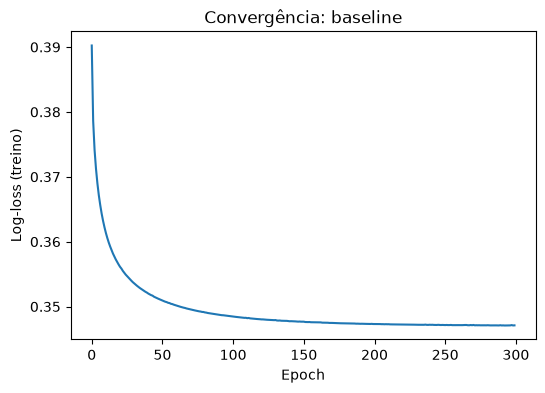

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
Treino,0.8545,0.7579,0.4164,0.5375,0.8628,0.6720
Validação,0.8415,0.7169,0.3915,0.5064,0.8478,0.6302


In [10]:
w_base, custo_base = treinar_logistica(dados["X_train"], dados["y_train"], lr=0.1, epochs=300, batch_size=256)

plt.figure(figsize=(6, 4))
plt.plot(custo_base)
plt.xlabel("Epoch")
plt.ylabel("Log-loss (treino)")
plt.title("Convergência: baseline")
plt.show()

metricas_base = pd.DataFrame({
    "Treino": avaliar_clf(w_base, dados["X_train"], dados["y_train"]),
    "Validação": avaliar_clf(w_base, dados["X_val"], dados["y_val"]),
}).T
metricas_base.round(4)

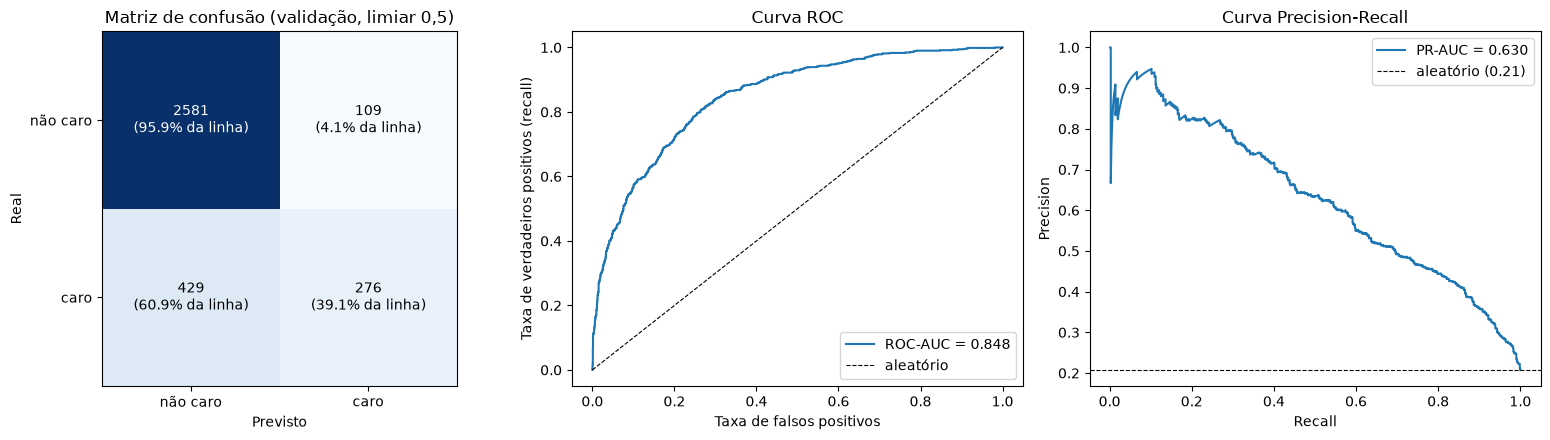

In [11]:
p_val_base = prever_proba(adicionar_bias(dados["X_val"]), w_base)

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
desenhar_matriz_confusao(eixos[0], dados["y_val"], (p_val_base >= 0.5).astype(int), "Matriz de confusão (validação, limiar 0,5)")
desenhar_curvas(eixos[1], eixos[2], dados["y_val"], p_val_base)
plt.tight_layout()
plt.show()

### Discussão

- **Resultado (validação, limiar 0,5):** accuracy **0,842**, precision **0,717**, recall **0,391**, F1 **0,506**, ROC-AUC **0,848** e PR-AUC **0,630**.
- **Accuracy enganadora:** com 20,8% de positivos, prever sempre "não caro" dá ≈**79,2%**; o modelo ganha apenas cerca de 5 pontos.
- **Capacidade de ordenar:** um ROC-AUC de 0,848 significa que um anúncio caro recebe uma probabilidade maior do que um não caro em ≈85% dos pares. O PR-AUC de 0,630 é cerca de **3 vezes** o de um classificador aleatório (0,208).
- **Limiar 0,5 conservador:** precision alta, mas só são detetados **39%** dos anúncios caros.
- **Sobreajuste:** ROC-AUC de 0,863 no treino contra 0,848 na validação, uma diferença de 0,015.

## 7. Análise do limiar de decisão

Com classes desequilibradas, o limiar 0,5 raramente é o melhor. Varia-se o limiar na validação e escolhe-se o que maximiza o F1 (nunca no teste).

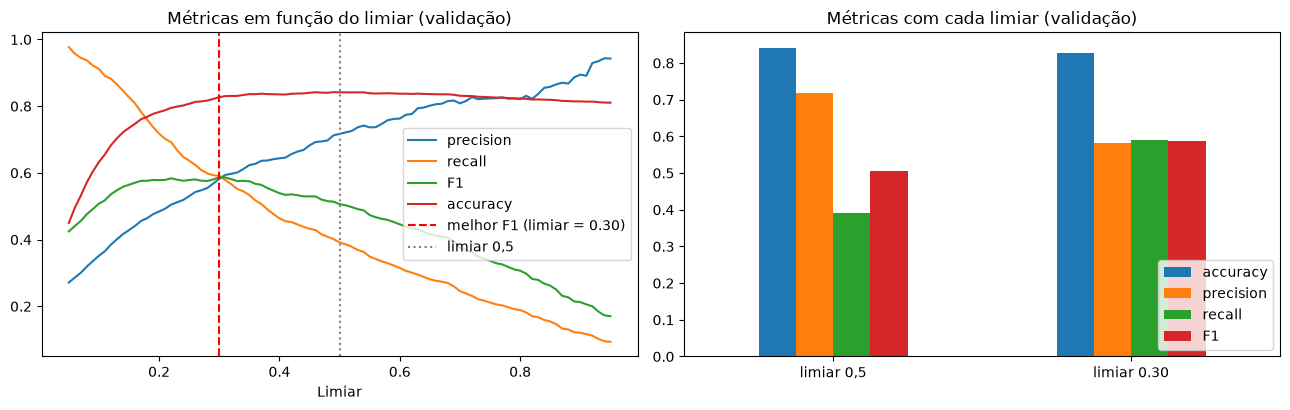

Limiar que maximiza o F1 na validação: 0.3


,accuracy,precision,recall,F1
"limiar 0,5",0.8415,0.7169,0.3915,0.5064
limiar 0.30,0.8271,0.5824,0.5915,0.5869


In [12]:
limiares = np.linspace(0.05, 0.95, 91)
tabela_limiar = pd.DataFrame([{"limiar": t, **metricas_limiar(dados["y_val"], p_val_base, t)} for t in limiares])
limiar_base = float(tabela_limiar.loc[tabela_limiar["F1"].idxmax(), "limiar"])

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.2))
for coluna in ["precision", "recall", "F1", "accuracy"]:
    eixos[0].plot(tabela_limiar["limiar"], tabela_limiar[coluna], label=coluna)
eixos[0].axvline(limiar_base, color="red", linestyle="--", label=f"melhor F1 (limiar = {limiar_base:.2f})")
eixos[0].axvline(0.5, color="gray", linestyle=":", label="limiar 0,5")
eixos[0].set_xlabel("Limiar")
eixos[0].set_title("Métricas em função do limiar (validação)")
eixos[0].legend()

comparacao = pd.DataFrame({
    "limiar 0,5": metricas_limiar(dados["y_val"], p_val_base, 0.5),
    f"limiar {limiar_base:.2f}": metricas_limiar(dados["y_val"], p_val_base, limiar_base),
}).T
comparacao.plot(kind="bar", ax=eixos[1], rot=0)
eixos[1].set_title("Métricas com cada limiar (validação)")
eixos[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Limiar que maximiza o F1 na validação:", limiar_base)
comparacao.round(4)

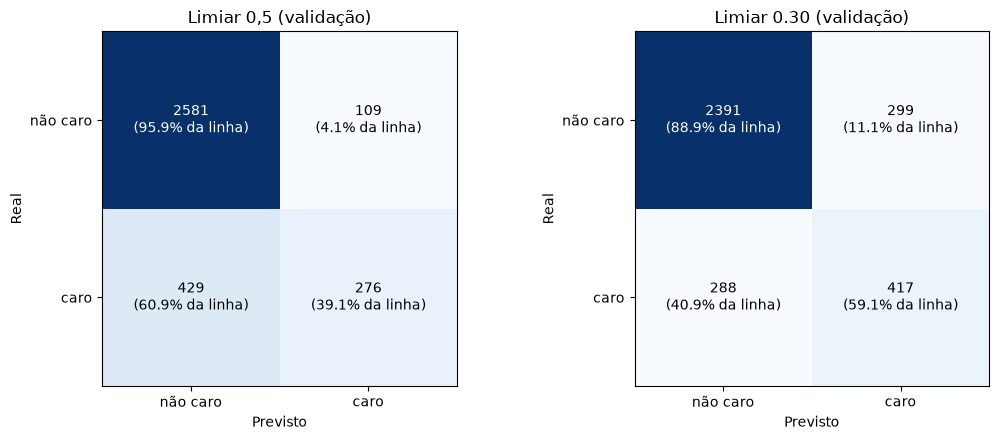

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))
desenhar_matriz_confusao(eixos[0], dados["y_val"], (p_val_base >= 0.5).astype(int), "Limiar 0,5 (validação)")
desenhar_matriz_confusao(eixos[1], dados["y_val"], (p_val_base >= limiar_base).astype(int), f"Limiar {limiar_base:.2f} (validação)")
plt.tight_layout()
plt.show()

### Discussão

- **Resultado:** o limiar que maximiza o F1 na validação é **0,30**. O recall sobe de **0,39 para 0,59** e o F1 de **0,51 para 0,59**, com a precision a descer de **0,72 para 0,58** e a accuracy de **0,84 para 0,83**.
- **Compromisso:** baixar o limiar deteta mais anúncios caros à custa de mais falsos positivos, como mostram as matrizes de confusão.
- **A escolha depende do objetivo:** para sinalizar anúncios sobrevalorizados convém privilegiar o recall; se um falso alarme for caro, um limiar mais alto.
- **Procedimento:** o limiar é escolhido na validação, nunca no teste.

## 8. Features polinomiais (graus 2 e 3)

Termos de grau superior em todas as variáveis numéricas não binárias, comparando os graus 2 e 3 com o modelo linear (grau 1). Por estabilidade numérica do gradient descent, os valores são limitados a 4 desvios-padrão (clip) antes de serem elevados à potência e, depois de as colunas novas serem padronizadas, voltam a ser limitados ao mesmo intervalo. Estas salvaguardas aplicam-se apenas às colunas novas.

In [14]:
def adicionar_polinomiais(X, feature_cols, cols_alvo, grau=2, limite=4.0):
    X_novo = X.copy()
    novos_nomes = list(feature_cols)
    for col in cols_alvo:
        idx = feature_cols.index(col)
        valor_limitado = np.clip(X[:, [idx]], -limite, limite)
        for p in range(2, grau + 1):
            X_novo = np.hstack([X_novo, valor_limitado ** p])
            novos_nomes.append(f"{col}^{p}")
    return X_novo, novos_nomes

def escalar_colunas_novas(X_train_novo, X_val_novo, n_colunas_originais, limite=4.0):
    media = X_train_novo[:, n_colunas_originais:].mean(axis=0)
    desvio = X_train_novo[:, n_colunas_originais:].std(axis=0)
    desvio[desvio == 0] = 1.0
    X_train_novo, X_val_novo = X_train_novo.copy(), X_val_novo.copy()
    X_train_novo[:, n_colunas_originais:] = np.clip((X_train_novo[:, n_colunas_originais:] - media) / desvio, -limite, limite)
    X_val_novo[:, n_colunas_originais:] = np.clip((X_val_novo[:, n_colunas_originais:] - media) / desvio, -limite, limite)
    return X_train_novo, X_val_novo

cols_para_polinomio = [
    col for j, col in enumerate(dados["feature_cols"])
    if np.unique(dados["X_train"][:, j]).size > 2
]
print("Colunas com termos polinomiais:", cols_para_polinomio)

resultados_poly = [{"grau": 1, "n_features": dados["X_train"].shape[1], **avaliar_clf(w_base, dados["X_val"], dados["y_val"])}]
for grau in [2, 3]:
    X_train_poly, _ = adicionar_polinomiais(dados["X_train"], dados["feature_cols"], cols_para_polinomio, grau)
    X_val_poly, _ = adicionar_polinomiais(dados["X_val"], dados["feature_cols"], cols_para_polinomio, grau)
    X_train_poly, X_val_poly = escalar_colunas_novas(X_train_poly, X_val_poly, len(dados["feature_cols"]))
    w_poly, _ = treinar_logistica(X_train_poly, dados["y_train"], lr=0.1, epochs=300, batch_size=256)
    resultados_poly.append({"grau": grau, "n_features": X_train_poly.shape[1], **avaliar_clf(w_poly, X_val_poly, dados["y_val"])})

df_poly = pd.DataFrame(resultados_poly)
df_poly

Colunas com termos polinomiais: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'availability_365', 'n_amenities']


,grau,n_features,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
0,1,43,0.841532,0.716883,0.391489,0.506422,0.847845,0.630174
1,2,53,0.848306,0.725118,0.434043,0.543035,0.857922,0.638296
2,3,63,0.845950,0.709677,0.436879,0.540825,0.861065,0.639565


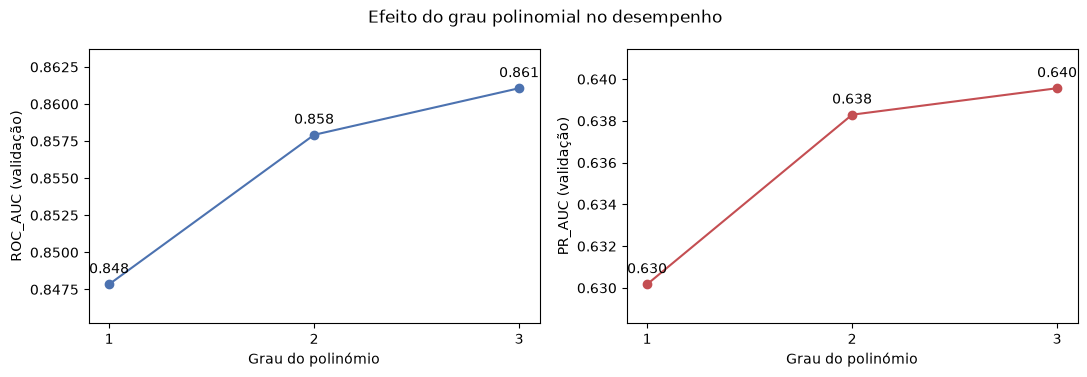

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8))
for eixo, metrica, cor in zip(eixos, ["ROC_AUC", "PR_AUC"], ["#4C72B0", "#C44E52"]):
    eixo.plot(df_poly["grau"], df_poly[metrica], marker="o", color=cor)
    for x, y in zip(df_poly["grau"], df_poly[metrica]):
        eixo.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
    eixo.set_xticks(df_poly["grau"])
    eixo.set_xlabel("Grau do polinómio")
    eixo.set_ylabel(metrica + " (validação)")
    eixo.margins(y=0.2)
plt.suptitle("Efeito do grau polinomial no desempenho")
plt.tight_layout()
plt.show()

### Discussão

- **Resultado (validação):** ROC-AUC **0,848 → 0,858 → 0,861** (graus 1, 2, 3); PR-AUC **0,630 → 0,638 → 0,640**; F1 a 0,5 **0,506 → 0,543 → 0,541**. Custo: de 43 para 63 variáveis.
- **Significância:** o ganho total de 0,013 em ROC-AUC equivale a cerca de **1,3 vezes** o desvio-padrão entre folds (0,010), pelo que a evidência é fraca: indica ligeira não linearidade, mas não é conclusiva.
- **Onde se nota:** sobretudo no recall a 0,5 (**0,391 → 0,434**). Como depende do limiar, deve ler-se com cautela.
- **Ressalvas:** comparação feita na validação; valores limitados a 4 desvios-padrão (secção 8); o modelo final fica linear (grau 1) para manter os coeficientes interpretáveis.

## 9. Features de interação

Acrescentam-se `accommodates × bedrooms` e `accommodates × bathrooms`, com as mesmas salvaguardas de estabilidade da secção anterior.

In [16]:
def adicionar_interacoes(X, feature_cols, pares, limite=4.0):
    X_novo = X.copy()
    novos_nomes = list(feature_cols)
    for a, b in pares:
        ia, ib = feature_cols.index(a), feature_cols.index(b)
        val_a = np.clip(X[:, [ia]], -limite, limite)
        val_b = np.clip(X[:, [ib]], -limite, limite)
        X_novo = np.hstack([X_novo, val_a * val_b])
        novos_nomes.append(f"{a}*{b}")
    return X_novo, novos_nomes

pares_interacao = [("accommodates", "bedrooms"), ("accommodates", "bathrooms")]
X_train_int, _ = adicionar_interacoes(dados["X_train"], dados["feature_cols"], pares_interacao)
X_val_int, _ = adicionar_interacoes(dados["X_val"], dados["feature_cols"], pares_interacao)
X_train_int, X_val_int = escalar_colunas_novas(X_train_int, X_val_int, len(dados["feature_cols"]))
w_int, _ = treinar_logistica(X_train_int, dados["y_train"], lr=0.1, epochs=300, batch_size=256)

df_interacoes = pd.DataFrame({
    "linear simples": avaliar_clf(w_base, dados["X_val"], dados["y_val"]),
    "com interações": avaliar_clf(w_int, X_val_int, dados["y_val"]),
}).T
df_interacoes.round(4)

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
linear simples,0.8415,0.7169,0.3915,0.5064,0.8478,0.6302
com interações,0.8409,0.7068,0.4000,0.5109,0.8546,0.6431


### 9.1. Comparação de todos os modelos

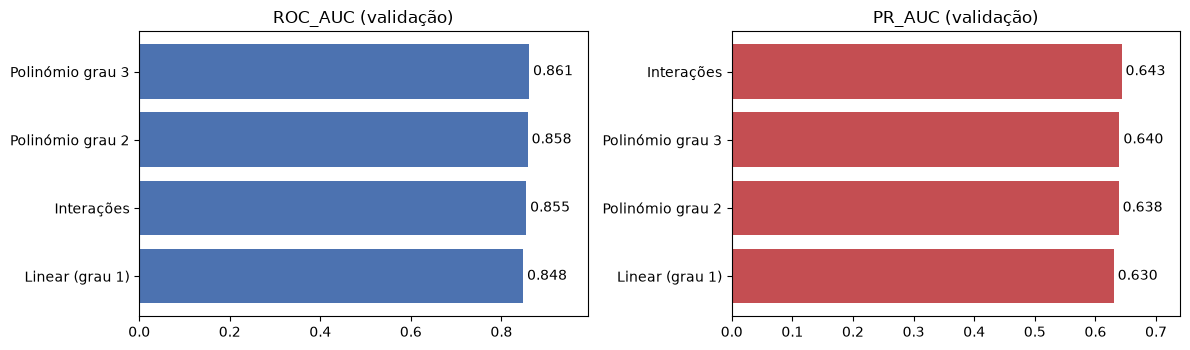

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
modelo,,,,,,
Linear (grau 1),0.8415,0.7169,0.3915,0.5064,0.8478,0.6302
Interações,0.8409,0.7068,0.4000,0.5109,0.8546,0.6431
Polinómio grau 2,0.8483,0.7251,0.4340,0.5430,0.8579,0.6383
Polinómio grau 3,0.8459,0.7097,0.4369,0.5408,0.8611,0.6396


In [17]:
linha_poly = lambda g: df_poly.loc[df_poly["grau"] == g, ["accuracy", "precision", "recall", "F1", "ROC_AUC", "PR_AUC"]].iloc[0].to_dict()
df_modelos = pd.DataFrame([
    {"modelo": "Linear (grau 1)", **avaliar_clf(w_base, dados["X_val"], dados["y_val"])},
    {"modelo": "Interações", **avaliar_clf(w_int, X_val_int, dados["y_val"])},
    {"modelo": "Polinómio grau 2", **linha_poly(2)},
    {"modelo": "Polinómio grau 3", **linha_poly(3)},
]).set_index("modelo").astype(float)

fig, eixos = plt.subplots(1, 2, figsize=(12, 3.6))
for eixo, metrica, cor in zip(eixos, ["ROC_AUC", "PR_AUC"], ["#4C72B0", "#C44E52"]):
    ordenado = df_modelos[metrica].sort_values()
    eixo.barh(ordenado.index, ordenado.values, color=cor)
    for y, v in enumerate(ordenado.values):
        eixo.text(v, y, f" {v:.3f}", va="center")
    eixo.set_title(metrica + " (validação)")
    eixo.margins(x=0.15)
plt.tight_layout()
plt.show()
df_modelos.round(4)

### Discussão

- **Interações:** ROC-AUC **0,848 → 0,855** (+0,007), PR-AUC **0,630 → 0,643** (+0,013) e F1 0,506 → 0,511, com apenas 2 variáveis novas. Os ganhos são inferiores a 1 desvio-padrão entre folds (0,010 em ROC-AUC e 0,020 em PR-AUC), logo não se distinguem de ruído.
- **Comparação dos quatro modelos:** a interação tem o melhor PR-AUC (**0,643**) e o grau 3 o melhor ROC-AUC (**0,861**), mas as diferenças são pequenas (≤0,013 em ROC-AUC). A interação consegue-o com 2 variáveis novas, contra 10 no grau 2 e 20 no grau 3.
- **Conclusão:** nenhum modelo se destaca de forma clara, e o linear é mantido pela interpretabilidade.

## 10. Regularização L2

Testa vários valores de lambda e escolhe o melhor pelo ROC-AUC na validação (em caso de empate, o menor lambda).

In [18]:
lambdas = [0, 0.1, 1, 10, 50, 100]
resultados_l2 = []
for l2 in lambdas:
    w, _ = treinar_logistica(dados["X_train"], dados["y_train"], lr=0.1, epochs=300, l2=l2, batch_size=256)
    resultados_l2.append({"lambda": l2, **avaliar_clf(w, dados["X_val"], dados["y_val"])})

df_l2 = pd.DataFrame(resultados_l2)
df_l2

,lambda,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
0,0.0,0.841532,0.716883,0.391489,0.506422,0.847845,0.630174
1,0.1,0.839764,0.722992,0.370213,0.489681,0.848129,0.629477
2,1.0,0.830928,0.706625,0.317730,0.438356,0.841935,0.615233
3,10.0,0.826215,0.764977,0.235461,0.360087,0.815847,0.580389
4,50.0,0.812371,0.861702,0.114894,0.202753,0.790686,0.560057
5,100.0,0.803240,0.911111,0.058156,0.109333,0.782442,0.554922


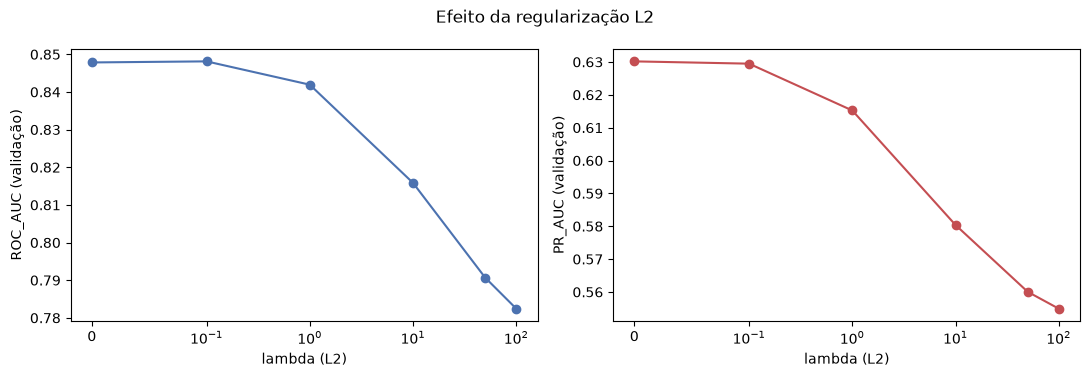

Melhor lambda: 0.1


In [19]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8))
for eixo, metrica, cor in zip(eixos, ["ROC_AUC", "PR_AUC"], ["#4C72B0", "#C44E52"]):
    eixo.plot(df_l2["lambda"], df_l2[metrica], marker="o", color=cor)
    eixo.set_xscale("symlog", linthresh=0.1)
    eixo.set_xlabel("lambda (L2)")
    eixo.set_ylabel(metrica + " (validação)")
plt.suptitle("Efeito da regularização L2")
plt.tight_layout()
plt.show()

melhor_lambda = float(df_l2.loc[df_l2["ROC_AUC"].idxmax(), "lambda"])
print("Melhor lambda:", melhor_lambda)

### Discussão

- **Resultado (ROC-AUC):** **0,848** (λ=0), **0,848** (λ=0,1), 0,842 (λ=1), 0,816 (λ=10), 0,791 (λ=50) e **0,782** (λ=100). O melhor é λ=**0,1**, mas a diferença para λ=0 é desprezável (+0,0003).
- **Efeito no limiar 0,5:** com λ alto, o recall colapsa (**0,39 → 0,06**) e a precision sobe (**0,72 → 0,91**), porque a penalização aproxima as probabilidades da taxa base (≈20%) e poucas ultrapassam 0,5.
- **Conclusão:** tal como na regressão linear, a regularização não traz benefício relevante (15846 observações para 43 variáveis). O λ=0,1 resulta de um desempate marginal.

## 11. K-fold cross-validation (implementado à mão)

5 folds sobre o conjunto de treino, com o melhor lambda.

In [20]:
def k_fold_indices(n, k=5, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n)
    tamanhos = [n // k + (1 if i < n % k else 0) for i in range(k)]
    folds, inicio = [], 0
    for tam in tamanhos:
        folds.append(indices[inicio:inicio + tam])
        inicio += tam
    return folds

def k_fold_cv_clf(X, y, k=5, lr=0.1, epochs=200, l2=0.0, batch_size=256, seed=SEED):
    folds = k_fold_indices(len(y), k, seed)
    metricas = []
    for i in range(k):
        idx_train = np.concatenate([folds[j] for j in range(k) if j != i])
        w, _ = treinar_logistica(X[idx_train], y[idx_train], lr=lr, epochs=epochs, l2=l2, batch_size=batch_size, seed=seed)
        metricas.append(avaliar_clf(w, X[folds[i]], y[folds[i]]))
    return pd.DataFrame(metricas)

df_kfold = k_fold_cv_clf(dados["X_train"], dados["y_train"], k=5, l2=melhor_lambda)
print(df_kfold.round(4))
print("\nMédia:", df_kfold.mean().round(4).to_dict())
print("Desvio-padrão:", df_kfold.std().round(4).to_dict())

   accuracy  precision  recall      F1  ROC_AUC  PR_AUC
0    0.8473     0.7560  0.3838  0.5091   0.8506  0.6558
1    0.8605     0.7869  0.4417  0.5658   0.8715  0.6976
2    0.8476     0.7310  0.3900  0.5086   0.8592  0.6610
3    0.8470     0.7333  0.3787  0.4995   0.8481  0.6462
4    0.8501     0.7357  0.3877  0.5078   0.8677  0.6536

Média: {'accuracy': 0.8505, 'precision': 0.7486, 'recall': 0.3964, 'F1': 0.5182, 'ROC_AUC': 0.8594, 'PR_AUC': 0.6628}
Desvio-padrão: {'accuracy': 0.0057, 'precision': 0.0236, 'recall': 0.0257, 'F1': 0.0269, 'ROC_AUC': 0.0103, 'PR_AUC': 0.0201}


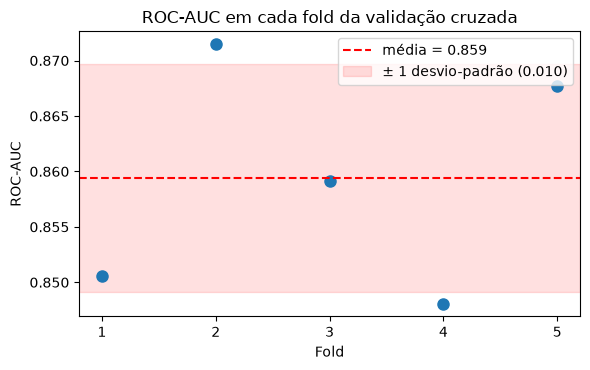

In [21]:
folds = np.arange(1, len(df_kfold) + 1)
media, desvio = df_kfold["ROC_AUC"].mean(), df_kfold["ROC_AUC"].std()
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(folds, df_kfold["ROC_AUC"], "o", markersize=8)
ax.axhline(media, color="red", linestyle="--", label=f"média = {media:.3f}")
ax.axhspan(media - desvio, media + desvio, color="red", alpha=0.12, label=f"± 1 desvio-padrão ({desvio:.3f})")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC em cada fold da validação cruzada")
ax.legend()
plt.tight_layout()
plt.show()

### Discussão

- **Resultado:** ROC-AUC **0,859 ± 0,010** (folds entre 0,848 e 0,872), PR-AUC **0,663 ± 0,020**, F1 **0,518 ± 0,027** e recall **0,396 ± 0,026**.
- **Estabilidade:** variação moderada entre folds. O PR-AUC, o F1 e o recall oscilam mais porque dependem apenas da classe minoritária (≈20% das observações).
- **Nota:** o ROC-AUC da validação (0,848) está no limite inferior dos folds, o que sugere uma partição ligeiramente mais difícil; o do teste (0,854) fica dentro do intervalo.

## 12. Modelo final e avaliação no teste

Treinado com o melhor lambda. O limiar é escolhido na validação (máximo F1) e aplicado ao teste, que só é usado para avaliar o modelo final.

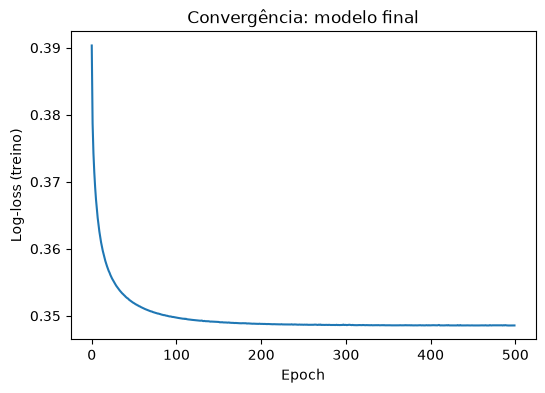

Limiar escolhido na validação (máximo F1): 0.22999999999999998


,accuracy,precision,recall,F1,ROC_AUC,PR_AUC
Treino,0.8084,0.5205,0.7166,0.6030,0.8629,0.6695
Validação,0.8038,0.5211,0.6823,0.5909,0.8482,0.6292
Teste,0.8015,0.4931,0.7050,0.5803,0.8542,0.6489


In [22]:
w_final, custo_final = treinar_logistica(dados["X_train"], dados["y_train"], lr=0.1, epochs=500, l2=melhor_lambda, batch_size=256)

plt.figure(figsize=(6, 4))
plt.plot(custo_final)
plt.xlabel("Epoch")
plt.ylabel("Log-loss (treino)")
plt.title("Convergência: modelo final")
plt.show()

p_val = prever_proba(adicionar_bias(dados["X_val"]), w_final)
p_teste = prever_proba(adicionar_bias(dados["X_test"]), w_final)
limiar_final = melhor_limiar(dados["y_val"], p_val)
print("Limiar escolhido na validação (máximo F1):", limiar_final)

metricas_finais = pd.DataFrame({
    "Treino": avaliar_clf(w_final, dados["X_train"], dados["y_train"], limiar_final),
    "Validação": avaliar_clf(w_final, dados["X_val"], dados["y_val"], limiar_final),
    "Teste": avaliar_clf(w_final, dados["X_test"], dados["y_test"], limiar_final),
}).T
metricas_finais.round(4)

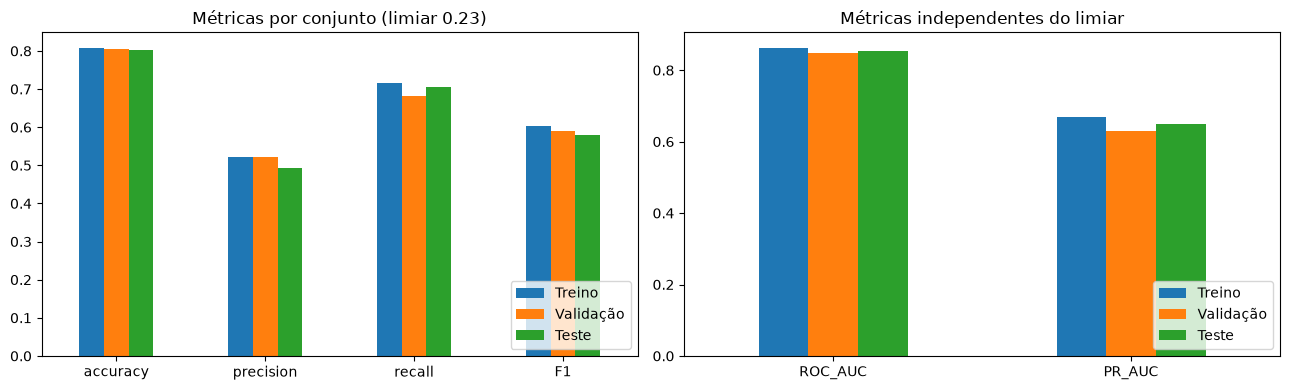

In [23]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
metricas_finais[["accuracy", "precision", "recall", "F1"]].T.plot(kind="bar", ax=eixos[0], rot=0)
eixos[0].set_title(f"Métricas por conjunto (limiar {limiar_final:.2f})")
eixos[0].legend(loc="lower right")
metricas_finais[["ROC_AUC", "PR_AUC"]].T.plot(kind="bar", ax=eixos[1], rot=0)
eixos[1].set_title("Métricas independentes do limiar")
eixos[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

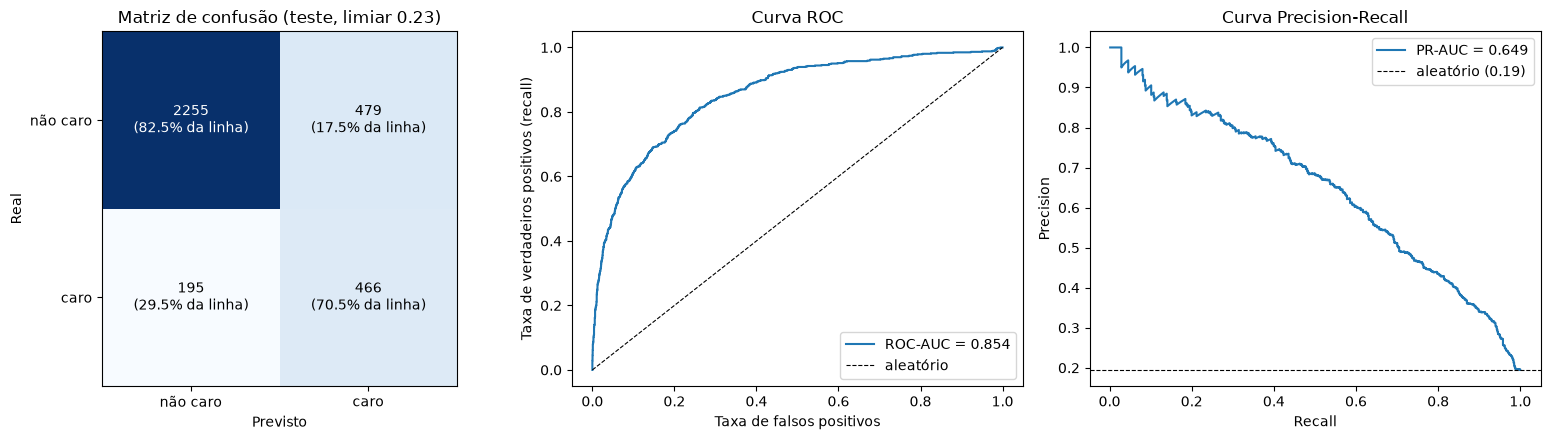

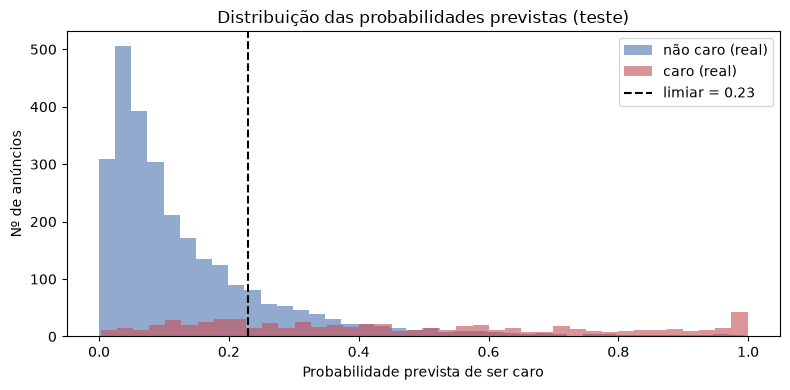

In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
desenhar_matriz_confusao(eixos[0], dados["y_test"], (p_teste >= limiar_final).astype(int), f"Matriz de confusão (teste, limiar {limiar_final:.2f})")
desenhar_curvas(eixos[1], eixos[2], dados["y_test"], p_teste)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(p_teste[dados["y_test"] == 0], bins=40, alpha=0.6, label="não caro (real)", color="#4C72B0")
ax.hist(p_teste[dados["y_test"] == 1], bins=40, alpha=0.6, label="caro (real)", color="#C44E52")
ax.axvline(limiar_final, color="black", linestyle="--", label=f"limiar = {limiar_final:.2f}")
ax.set_xlabel("Probabilidade prevista de ser caro")
ax.set_ylabel("Nº de anúncios")
ax.set_title("Distribuição das probabilidades previstas (teste)")
ax.legend()
plt.tight_layout()
plt.show()

### Discussão

- **Resultado (teste, limiar 0,23):** accuracy **0,801**, precision **0,493**, recall **0,705**, F1 **0,580**, ROC-AUC **0,854** e PR-AUC **0,649**.
- **Consistência:** ROC-AUC de 0,863 (treino), 0,848 (validação) e 0,854 (teste), sem sobreajuste relevante.
- **Accuracy:** os 80,1% do teste ficam ligeiramente abaixo do classificador trivial (80,5%, com 19,5% de positivos). É o preço de um recall de 70%, por isso a accuracy não é o critério adequado.
- **Utilidade:** o modelo deteta ≈**70%** dos anúncios caros e **49%** dos sinalizados são realmente caros, cerca de **2,5 vezes** a taxa base (19,5%).
- **Sobreposição das classes:** os anúncios não caros concentram-se abaixo de 0,2, mas os caros espalham-se por todo o intervalo, com sobreposição considerável abaixo de 0,4. Parte dos anúncios caros tem um perfil indistinguível dos restantes com as variáveis disponíveis.
- **Limiar:** escolhido na validação (0,23, máximo F1); o recall mantém-se no teste (0,682 na validação e 0,705 no teste).

## 13. Erros de classificação por bairro e por tipo de quarto (teste)

Como o alvo é definido dentro de cada grupo, a proporção de positivos é semelhante em todos eles, o que torna as taxas de erro comparáveis entre grupos.


--- Erros por room_type ---
          grupo    n  positivos_reais  taxa_erro  recall  precision
Entire home/apt 2542              512      0.174   0.734      0.551
   Private room  817              136      0.257   0.632      0.350
    Shared room   20                8      0.450   0.375      0.429
     Hotel room   16                5      0.750   0.200      0.111

--- Erros por neighbourhood_cleansed ---
                                            grupo   n  positivos_reais  taxa_erro  recall  precision
                                         Ericeira 102               23      0.137   0.826      0.655
                                            Other 871              164      0.163   0.793      0.546
                                Cascais e Estoril 223               39      0.170   0.692      0.509
                                   Penha de Frana  96               15      0.177   0.667      0.455
                                          Colares  65                8      0.185   

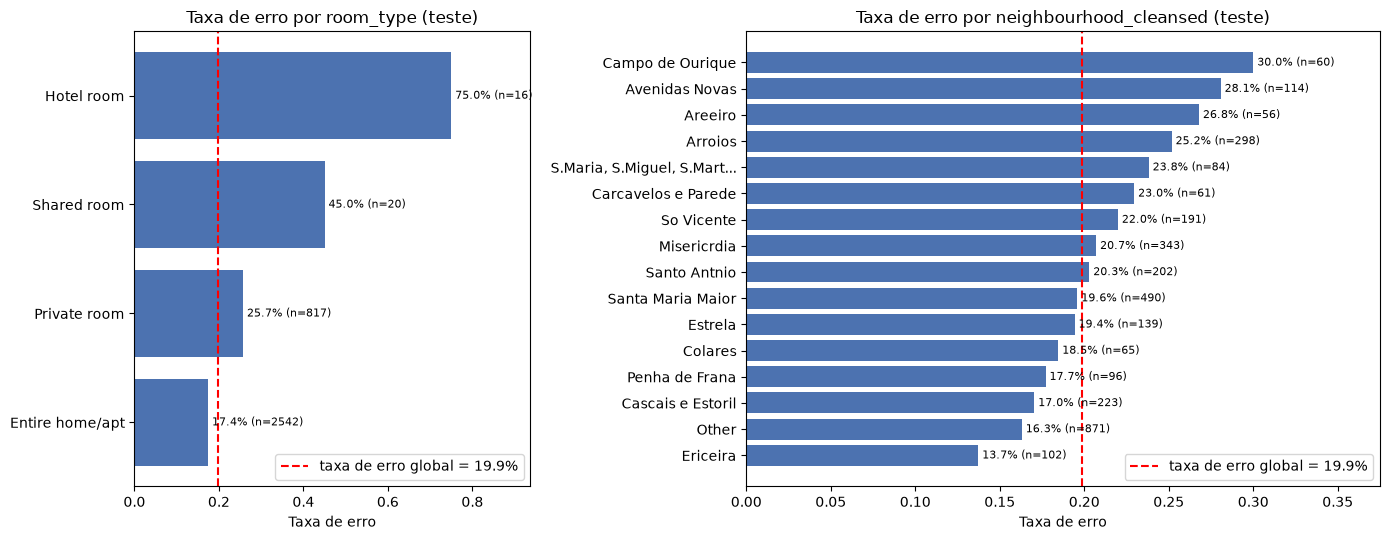

In [25]:
teste_df = dados["test_df_raw"].copy()
pred_teste = (p_teste >= limiar_final).astype(int)
erro_global = float(np.mean(pred_teste != dados["y_test"]))

abreviar = lambda s: s if len(s) <= 28 else s[:25] + "..."
fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.6]})
for eixo, prefixo in zip(eixos, ["room_type_", "neighbourhood_cleansed_"]):
    linhas = []
    for c in [c for c in teste_df.columns if c.startswith(prefixo)]:
        mask = (teste_df[c] == 1).values
        if mask.sum() > 0:
            y_g, pred_g = dados["y_test"][mask], pred_teste[mask]
            positivos = int(y_g.sum())
            linhas.append({
                "grupo": c[len(prefixo):], "n": int(mask.sum()), "positivos_reais": positivos,
                "taxa_erro": float(np.mean(pred_g != y_g)),
                "recall": float(np.sum((pred_g == 1) & (y_g == 1)) / positivos) if positivos > 0 else np.nan,
                "precision": float(np.sum((pred_g == 1) & (y_g == 1)) / np.sum(pred_g == 1)) if np.sum(pred_g == 1) > 0 else np.nan,
            })
    tabela = pd.DataFrame(linhas).sort_values("taxa_erro")
    print(f"\n--- Erros por {prefixo[:-1]} ---")
    print(tabela.round(3).to_string(index=False))

    eixo.barh([abreviar(g) for g in tabela["grupo"]], tabela["taxa_erro"], color="#4C72B0")
    for y, (t, n) in enumerate(zip(tabela["taxa_erro"], tabela["n"])):
        eixo.text(t, y, f" {t:.1%} (n={n})", va="center", fontsize=8)
    eixo.axvline(erro_global, color="red", linestyle="--", label=f"taxa de erro global = {erro_global:.1%}")
    eixo.set_xlabel("Taxa de erro")
    eixo.set_title(f"Taxa de erro por {prefixo[:-1]} (teste)")
    eixo.margins(x=0.25)
    eixo.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Discussão

- **Taxa de erro global (teste):** ≈**20%**.
- **Por tipo de quarto:** `Entire home/apt` **17,4%** (recall 0,73, precision 0,55, n=2542) e `Private room` **25,7%** (recall 0,63, precision 0,35, n=817), com mais falsos positivos nos quartos privados. `Shared room` (45%, n=20) e `Hotel room` (75%, n=16) têm amostras demasiado pequenas.
- **Por bairro:** menores erros em Ericeira (**13,7%**), `Other` (**16,3%**) e Cascais e Estoril (**17,0%**); maiores em Campo de Ourique (**30,0%**, n=60), Avenidas Novas (**28,1%**) e Areeiro (**26,8%**).
- **Contraste com a regressão:** Cascais e Estoril teve um dos maiores erros em euros, mas aqui está entre os menores, porque o alvo é relativo ao grupo e o prémio de preço do bairro deixa de pesar.
- **Cautela:** vários bairros têm poucos positivos (Campo de Ourique, 9; Areeiro, 10), pelo que as taxas são instáveis.

## 14. Tabela de coeficientes e odds ratios

Cada coeficiente é a variação do log-odds de o anúncio ser caro; `odds_ratio = exp(coeficiente)` é o fator multiplicativo nas odds. Nas variáveis numéricas (padronizadas) refere-se ao aumento de um desvio-padrão. Nas categóricas (one-hot) só as diferenças dentro da mesma variável são interpretáveis, porque a decomposição face ao termo constante não é única.

In [26]:
coef_df = pd.DataFrame({
    "feature": ["bias"] + dados["feature_cols"],
    "coeficiente": w_final,
})
coef_df["odds_ratio"] = np.exp(coef_df["coeficiente"])
coef_df = coef_df.sort_values("coeficiente", key=abs, ascending=False)
coef_df.round(3)

,feature,coeficiente,odds_ratio
34,neighbourhood_cleansed_Colares,-1.488,0.226
0,bias,-1.029,0.357
13,room_type_Entire home/apt,-0.981,0.375
1,accommodates,0.976,2.655
26,property_type_Private room in rental unit,-0.972,0.378
15,room_type_Private room,0.904,2.470
27,property_type_Room in hotel,0.896,2.451
40,"neighbourhood_cleansed_S.Maria, S.Miguel, S.Ma...",-0.762,0.467
35,neighbourhood_cleansed_Ericeira,-0.735,0.479
43,neighbourhood_cleansed_So Vicente,0.672,1.958


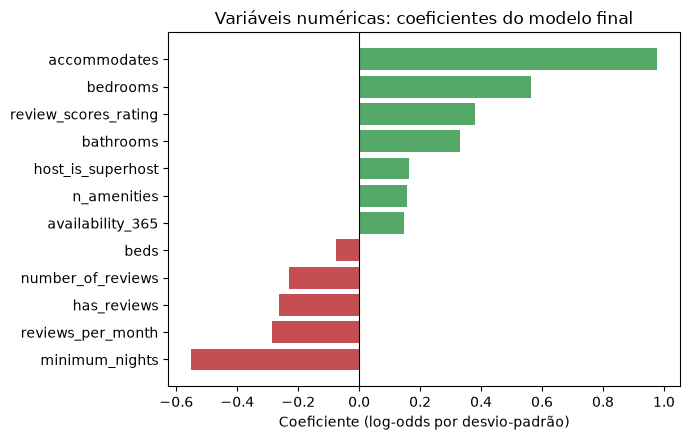

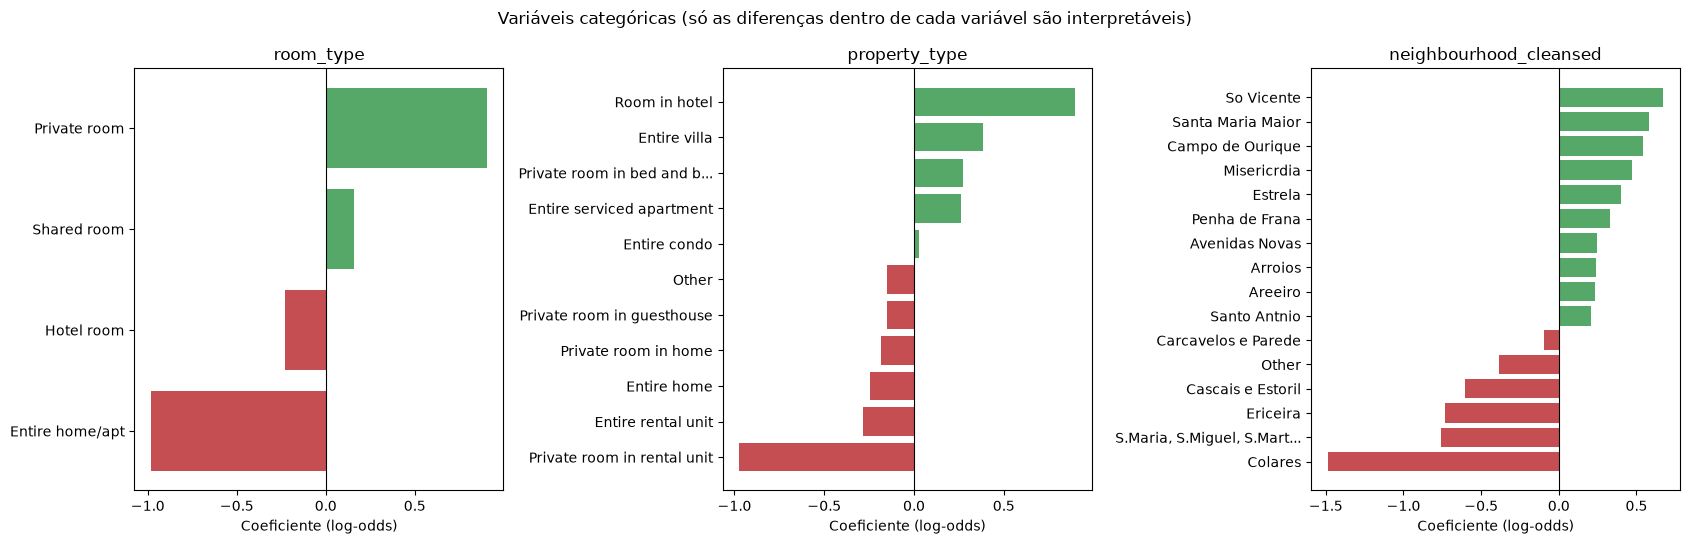

In [27]:
coef = pd.Series(w_final[1:], index=dados["feature_cols"])
prefixos = ["room_type_", "property_type_", "neighbourhood_cleansed_"]
numericas = [c for c in coef.index if not c.startswith(tuple(prefixos))]
abreviar = lambda s: s if len(s) <= 28 else s[:25] + "..."
cor_sinal = lambda s: np.where(s.values > 0, "#55A868", "#C44E52")

ordenado = coef[numericas].sort_values()
plt.figure(figsize=(7, 4.5))
plt.barh(ordenado.index, ordenado.values, color=cor_sinal(ordenado))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (log-odds por desvio-padrão)")
plt.title("Variáveis numéricas: coeficientes do modelo final")
plt.tight_layout()
plt.show()

fig, eixos = plt.subplots(1, 3, figsize=(17, 5.5))
for eixo, prefixo in zip(eixos, prefixos):
    s = coef[[c for c in coef.index if c.startswith(prefixo)]].sort_values()
    eixo.barh([abreviar(c[len(prefixo):]) for c in s.index], s.values, color=cor_sinal(s))
    eixo.axvline(0, color="black", linewidth=0.8)
    eixo.set_title(prefixo[:-1])
    eixo.set_xlabel("Coeficiente (log-odds)")
fig.suptitle("Variáveis categóricas (só as diferenças dentro de cada variável são interpretáveis)")
plt.tight_layout()
plt.show()

### Discussão

- **Como ler:** os coeficientes são log-odds (odds ratio por desvio-padrão nas numéricas; nas categóricas só as diferenças dentro da variável). Como o alvo é relativo a cada grupo de tipo de quarto e bairro, os coeficientes dessas variáveis não medem prémios de preço, mas a probabilidade de estar no top 20% do próprio grupo, dado o perfil do anúncio.
- **Numéricas:** `accommodates` domina (**+0,98**, odds ratio ≈**2,7**: cada desvio-padrão multiplica as odds de ser caro por esse fator), seguido de `bedrooms` (+0,56; OR 1,76), `minimum_nights` (**-0,55**; OR 0,58) e `review_scores_rating` (+0,38; OR 1,46). `bathrooms` (+0,33) tem o sinal esperado.
- **Reputação e atividade:** `reviews_per_month` (-0,29), `has_reviews` (-0,26) e `number_of_reviews` (-0,23) são negativos, em linha com a regressão linear (anúncios mais baratos têm maior rotação). `host_is_superhost` (+0,16), `n_amenities` (+0,16) e `availability_365` (+0,15) são pequenos; `beds` (-0,08) é praticamente nulo, por ser um efeito parcial.
- **Tipo de quarto:** `Private room` (+0,90) e `Entire home/apt` (-0,98) parecem invertidos face à regressão linear. Interpretação possível, não testada: as variáveis de dimensão já elevam a probabilidade dos alojamentos inteiros, e a categoria compensa esse efeito.
- **Bairros:** os mais baixos são Colares (**-1,49**), Sintra (-0,76), Ericeira (-0,74) e Cascais e Estoril (-0,60); os mais altos São Vicente (+0,67), Santa Maria Maior (+0,58) e Campo de Ourique (+0,54). Colares e Cascais e Estoril têm os preços medianos mais elevados na análise exploratória, pelo que o mesmo perfil é menos provável de estar no top 20% local.